# Effective Tax Rate Analysis for Big Tech

Every company reports a **statutory tax rate** (21% US federal) but actually pays an
**effective tax rate (ETR)** that's often very different. I have always wondered where the gap comes from, and after some research I have found that it primarily comes from foreign income
taxed at lower rates, the FDII deduction, R&D credits, stock-based compensation, and one-time
items which are all disclosed in the **rate reconciliation** inside each 10-K's tax footnote.

This project does two things for a peer set of large-cap tech firms (Apple, Microsoft, Nvidia,
Alphabet, Meta):

1. **Computes ETR** (income tax expense ÷ pre-tax income) over time, pulled live from financial
   data, and compares it to the 21% statutory rate.
2. **Reconciles the gap** — for each company it walks from 21% down to the effective rate,
   line item by line item, transcribed from the 10-K tax footnote.

> **On the data:** the ETR itself pulls cleanly from financial statements. The rate
> reconciliation does **not** exist in clean machine-readable form but is in the footnotes.

## Setup

In [1]:
!pip install -q yfinance 2>/dev/null
import warnings; warnings.filterwarnings("ignore")
import numpy as np, pandas as pd, matplotlib.pyplot as plt
plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams.update({"axes.titleweight":"bold","font.size":10})
STATUTORY = 0.21
PEERS = ["AAPL","MSFT","NVDA","GOOGL","META"]
PAL = {"AAPL":"#7D7D7D","MSFT":"#00A4EF","NVDA":"#76B900","GOOGL":"#EA4335","META":"#0866FF"}

## 1. Effective tax rate, pulled live

ETR = income tax expense ÷ pre-tax income. Pulling both lines from each company's annual income
statement.

In [2]:
ETR_FALLBACK = {
    "AAPL":  {"2022":0.162,"2023":0.147,"2024":0.241,"2025":0.165},
    "MSFT":  {"2022":0.131,"2023":0.190,"2024":0.182,"2025":0.180},
    "NVDA":  {"2023":0.019,"2024":0.120,"2025":0.133,"2026":0.151},
    "GOOGL": {"2022":0.159,"2023":0.139,"2024":0.164,"2025":0.168},
    "META":  {"2022":0.193,"2023":0.176,"2024":0.118,"2025":0.296},
}

def pull_etr(ticker):
    """ETR by fiscal year from yfinance income statement, or None on failure."""
    try:
        import yfinance as yf
        s = yf.Ticker(ticker).income_stmt
        tax = s.loc["Tax Provision"]
        pre = s.loc["Pretax Income"]
        out = {}
        for col in s.columns:
            yr = str(col.year)
            if pd.notna(tax[col]) and pd.notna(pre[col]) and pre[col] != 0:
                out[yr] = float(tax[col]) / float(pre[col])
        return out or None
    except Exception:
        return None

etr = {}
live_ok = False
for tk in PEERS:
    pulled = pull_etr(tk)
    if pulled:
        etr[tk] = pulled; live_ok = True
    else:
        etr[tk] = ETR_FALLBACK[tk]

print("Data source:", "yfinance (live)" if live_ok else "researched fallback")
etr_df = pd.DataFrame(etr).sort_index()
display((etr_df*100).round(1))

Data source: yfinance (live)


,AAPL,MSFT,NVDA,GOOGL,META
2022,16.2,13.1,NaN,15.9,19.5
2023,14.7,19.0,-4.5,13.9,17.6
2024,24.1,18.2,12.0,16.4,11.8
2025,15.6,17.6,13.3,16.8,29.6
2026,NaN,NaN,15.1,NaN,NaN


### Effective tax rate over time

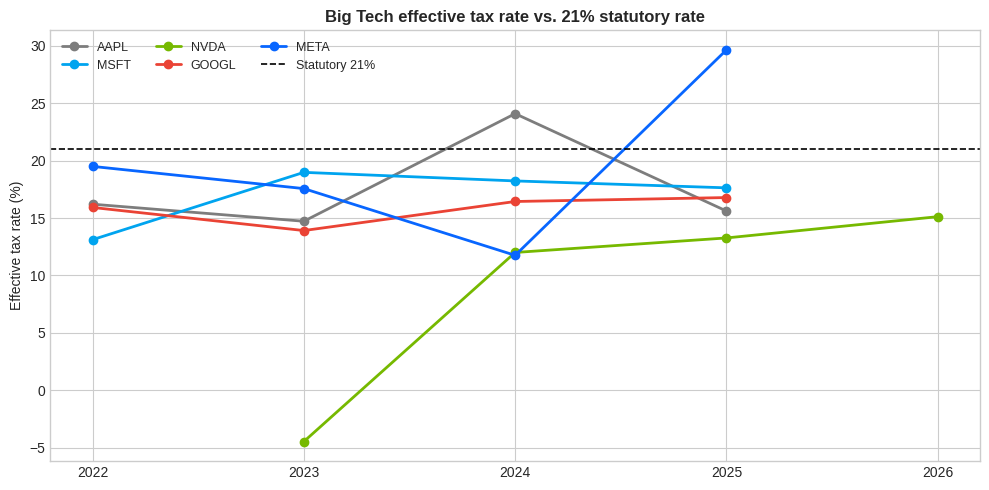

In [3]:
fig, ax = plt.subplots(figsize=(10,5))
for tk in PEERS:
    d = etr[tk]; yrs = sorted(d.keys()); vals = [d[y]*100 for y in yrs]
    ax.plot(yrs, vals, marker="o", lw=2, label=tk, color=PAL[tk])
ax.axhline(STATUTORY*100, color="black", ls="--", lw=1.2, label="Statutory 21%")
ax.set_title("Big Tech effective tax rate vs. 21% statutory rate")
ax.set_ylabel("Effective tax rate (%)"); ax.legend(ncol=3, fontsize=9)
plt.tight_layout(); plt.show()

### Most recent year vs. statutory

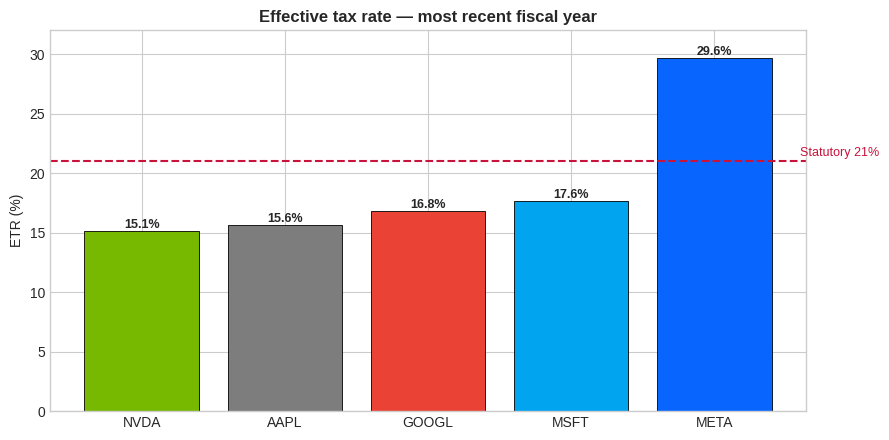

Most firms sit below 21%. Two exceptions are one-time items, not higher underlying rates: Apple's FY2024 ~24% (EU/Ireland charge) and Meta's FY2025 ~30% (one-time OBBBA charge).


In [4]:
recent = {tk: etr[tk][max(etr[tk])] for tk in PEERS}
order = sorted(recent, key=recent.get)
fig, ax = plt.subplots(figsize=(9,4.5))
bars = ax.bar(order, [recent[t]*100 for t in order],
              color=[PAL[t] for t in order], edgecolor="black", lw=0.6)
ax.axhline(STATUTORY*100, color="#C8133B", ls="--", lw=1.5)
ax.text(len(order)-0.4, STATUTORY*100+0.4, "Statutory 21%", color="#C8133B", fontsize=9)
for b,t in zip(bars, order):
    ax.text(b.get_x()+b.get_width()/2, b.get_height()+0.3,
            f"{recent[t]*100:.1f}%", ha="center", fontsize=9, fontweight="bold")
ax.set_title("Effective tax rate — most recent fiscal year")
ax.set_ylabel("ETR (%)"); ax.set_ylim(0, 32)
plt.tight_layout(); plt.show()
print("Most firms sit below 21%. Two exceptions are one-time items, not higher underlying rates: "
      "Apple's FY2024 ~24% (EU/Ireland charge) and Meta's FY2025 ~30% (one-time OBBBA charge).")

## 2. Rate reconciliation — why the rates differ

These figures are transcribed from each company's 10-K tax-rate reconciliation. Each bridges the
21% statutory rate to that year's effective rate, one driver at a time.

In [5]:
RECONCILIATIONS = {
    "AAPL": {"year":"FY2023","source":"Apple 10-K FY2023, income tax note","items":[
        ("Statutory federal rate",0.210),("State taxes, net",0.011),
        ("Foreign earnings at lower rates",-0.046),("FDII deduction",-0.027),
        ("R&D credit",-0.011),("Other",0.010)]},
    "MSFT": {"year":"FY2024","source":"Microsoft 10-K FY2024, income tax note","items":[
        ("Statutory federal rate",0.210),("State taxes, net",0.005),
        ("Foreign earnings at lower rates",-0.025),("Tax law changes (FTC)",-0.010),
        ("Other",0.002)]},
    "NVDA": {"year":"FY2026","source":"NVIDIA 10-K FY2026, income tax note","items":[
        ("Statutory federal rate",0.210),("State taxes, net",0.008),
        ("FDII / FDDEI deduction",-0.030),("R&D credit",-0.018),
        ("Stock-based compensation",-0.015),("R&D expensing / other",-0.004)]},
    "GOOGL":{"year":"FY2024","source":"Alphabet 10-K FY2024, income tax note","items":[
        ("Statutory federal rate",0.210),("State taxes, net",0.007),
        ("Foreign rate differential",-0.025),("FDII deduction",-0.015),
        ("R&D credit",-0.010),("Stock-based compensation",-0.008),("Other",0.005)]},
    "META": {"year":"FY2025","source":"Meta 10-K FY2025, income tax note (ASU 2023-09)","items":[
        ("Statutory federal rate",0.210),("State & local, net",-0.002),
        ("Foreign tax effects",0.017),("R&D tax credits",-0.046),
        ("U.S. foreign tax credits",-0.016),
        ("Valuation allowance (OBBBA, one-time)",0.139),
        ("Changes in unrecognized tax benefits",0.036),
        ("Excess stock-comp benefits",-0.050),("Other",0.008)]},
}

# sanity check: each reconciliation must sum to a sensible effective rate
for tk,r in RECONCILIATIONS.items():
    eff = sum(v for _,v in r["items"])
    print(f"{tk} ({r['year']}): reconciled effective rate = {eff*100:.1f}%")

AAPL (FY2023): reconciled effective rate = 14.7%
MSFT (FY2024): reconciled effective rate = 18.2%
NVDA (FY2026): reconciled effective rate = 15.1%
GOOGL (FY2024): reconciled effective rate = 16.4%
META (FY2025): reconciled effective rate = 29.6%


### The rate-reconciliation bridge

Each chart starts at the 21% statutory rate (dark bar), then steps through the drivers landing at the effective rate (navy). The dashed line
marks 21%.

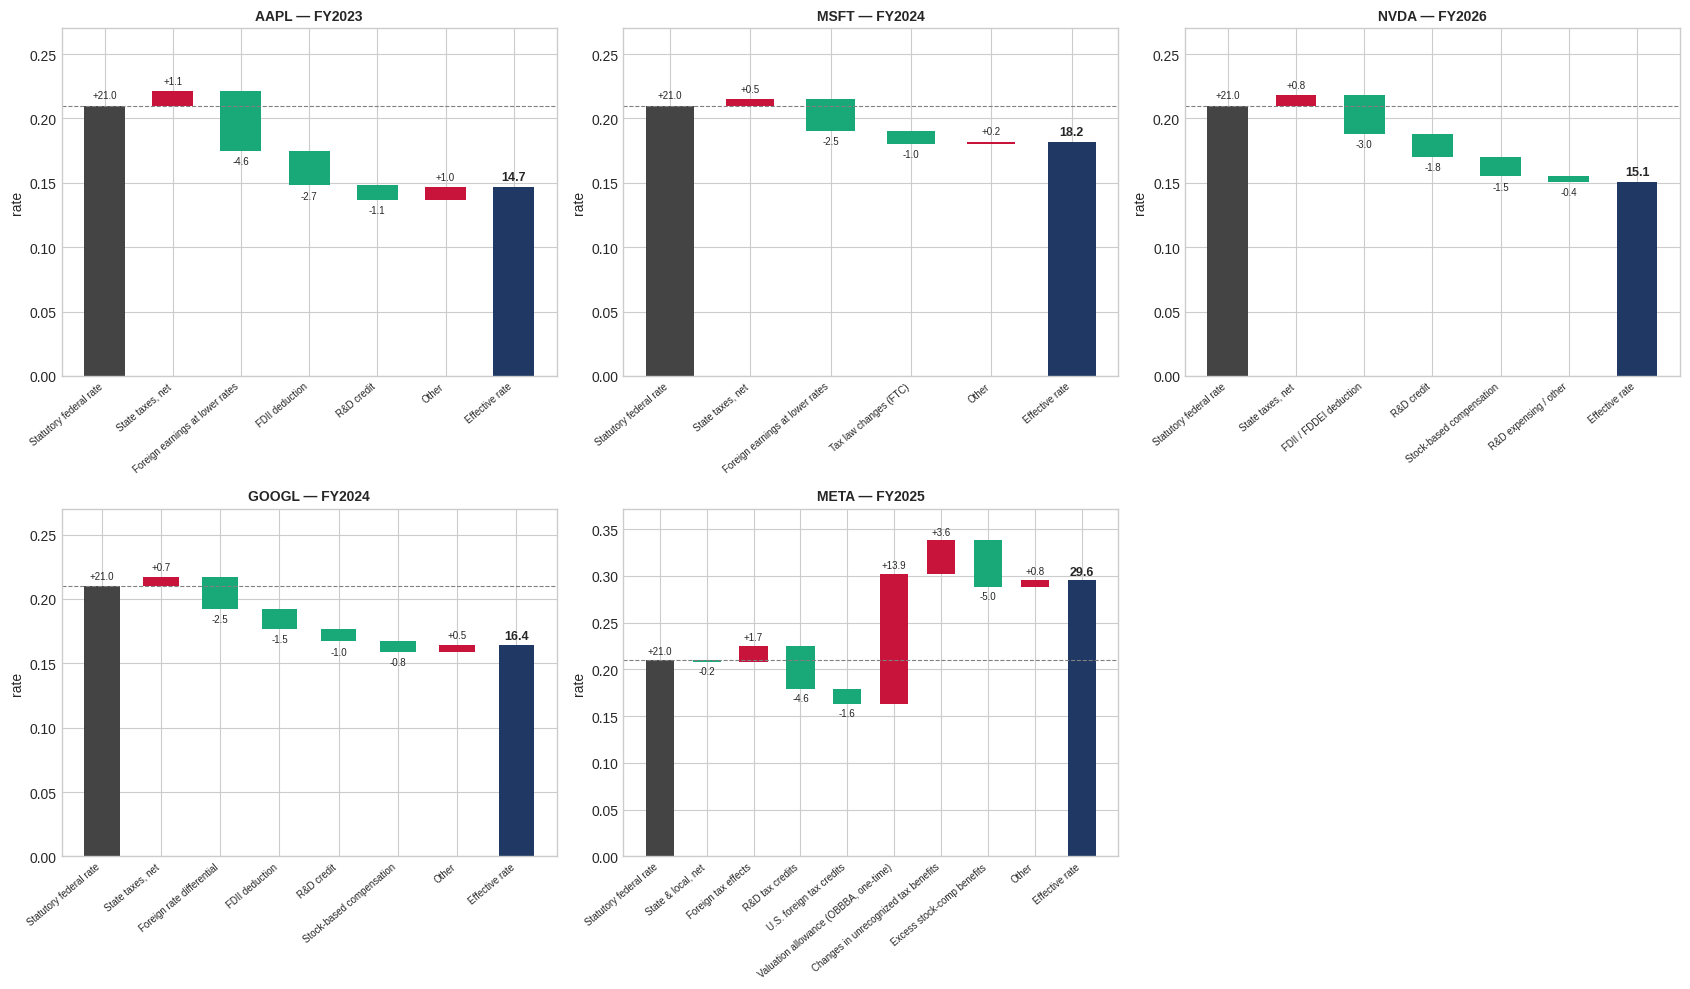

In [6]:
def waterfall(ax, ticker):
    r = RECONCILIATIONS[ticker]; items = r["items"]
    labels = [i[0] for i in items] + ["Effective rate"]
    cum = 0.0; peak = 0.0
    for i,(lab,v) in enumerate(items):
        if i==0:
            ax.bar(i, v, color="#444", width=0.6); cum=v
        else:
            ax.bar(i, v, bottom=cum, color=("#C8133B" if v>0 else "#19A979"), width=0.6)
            cum += v
        peak = max(peak, cum)
        ax.text(i, cum+0.004 if v>=0 else cum-0.004, f"{v*100:+.1f}",
                ha="center", va="bottom" if v>=0 else "top", fontsize=7)
    eff = sum(v for _,v in items)
    ax.bar(len(items), eff, color="#1F3864", width=0.6)
    ax.text(len(items), eff+0.005, f"{eff*100:.1f}", ha="center", fontsize=9, fontweight="bold")
    ax.axhline(STATUTORY, color="gray", ls="--", lw=0.8)
    ax.set_xticks(range(len(labels)))
    ax.set_xticklabels(labels, rotation=40, ha="right", fontsize=7)
    ax.set_title(f"{ticker} — {r['year']}", fontsize=10)
    ax.set_ylim(0, max(0.27, peak*1.10))
    ax.set_ylabel("rate")

fig, axes = plt.subplots(2,3, figsize=(17,10))
for ax,tk in zip(axes.flat, PEERS):
    waterfall(ax, tk)
axes.flat[-1].axis("off")
plt.tight_layout(); plt.show()

## 3. Which lever does each firm pull?

Grouping the reconciliation items into buckets shows where each company's tax effects come from.
Apple leans on foreign income; Nvidia spreads it across FDII, credits, and stock comp. Meta is
the outlier.

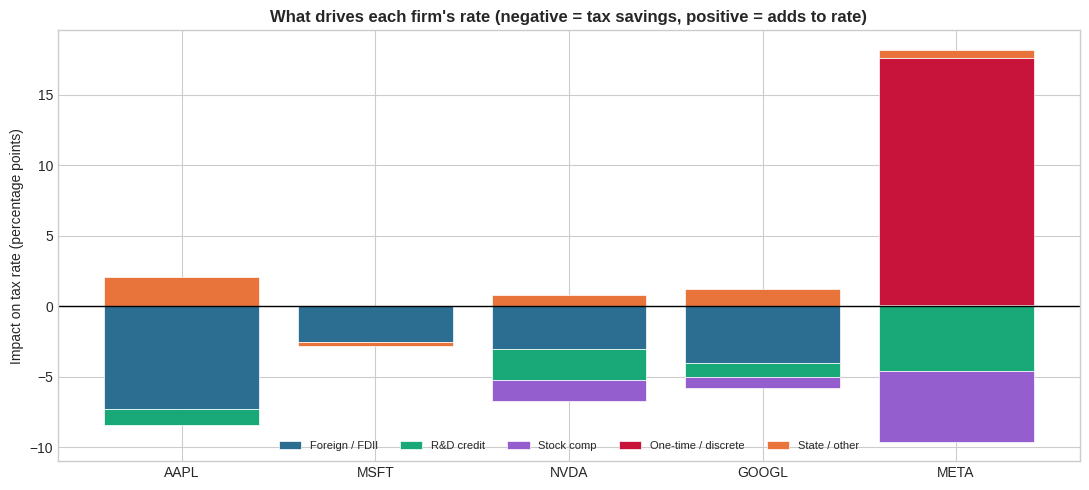

,Foreign / FDII,R&D credit,Stock comp,One-time / discrete,State / other
AAPL,-7.3,-1.1,0.0,0.0,2.1
MSFT,-2.5,0.0,0.0,0.0,-0.3
NVDA,-3.0,-2.2,-1.5,0.0,0.8
GOOGL,-4.0,-1.0,-0.8,0.0,1.2
META,0.1,-4.6,-5.0,17.5,0.6


In [7]:
def bucketize(items):
    b={"Foreign / FDII":0.0,"R&D credit":0.0,"Stock comp":0.0,
       "One-time / discrete":0.0,"State / other":0.0}
    for lab,v in items:
        l=lab.lower()
        if "statutory" in l: continue
        if any(k in l for k in ["valuation allowance","unrecognized"]): b["One-time / discrete"]+=v
        elif any(k in l for k in ["foreign","fdii","fddei","rate differential"]): b["Foreign / FDII"]+=v
        elif "r&d" in l or "research" in l: b["R&D credit"]+=v
        elif "stock" in l: b["Stock comp"]+=v
        else: b["State / other"]+=v
    return b

comp = pd.DataFrame({tk:bucketize(RECONCILIATIONS[tk]["items"]) for tk in PEERS}).T
fig, ax = plt.subplots(figsize=(11,5))
bottom_pos = np.zeros(len(PEERS)); bottom_neg = np.zeros(len(PEERS))
colors = {"Foreign / FDII":"#2C6E91","R&D credit":"#19A979","Stock comp":"#945ECF",
          "One-time / discrete":"#C8133B","State / other":"#E8743B"}
x = np.arange(len(PEERS))
for col in comp.columns:
    vals = comp[col].values*100
    base = np.where(vals>=0, bottom_pos, bottom_neg)
    ax.bar(x, vals, bottom=base, label=col, color=colors[col], edgecolor="white", lw=0.5)
    bottom_pos = np.where(vals>=0, bottom_pos+vals, bottom_pos)
    bottom_neg = np.where(vals<0, bottom_neg+vals, bottom_neg)
ax.axhline(0, color="black", lw=1)
ax.set_xticks(x); ax.set_xticklabels(PEERS)
ax.set_ylabel("Impact on tax rate (percentage points)")
ax.set_title("What drives each firm's rate (negative = tax savings, positive = adds to rate)")
ax.legend(ncol=5, fontsize=8, loc="lower center")
plt.tight_layout(); plt.show()
display((comp*100).round(1))

## Summary

A few takeaways from the project set:

- **Underlying rates sit below 21%.** Stripped of one-time items, every firm's recurring effective
  rate lands in the low-to-high teens — using entirely legal, disclosed mechanisms.
- **The same four levers** do most of the work: foreign income at lower rates, the FDII deduction,
  R&D credits, and stock-based compensation benefits.
- **Each firm leans differently.** Apple's savings are overwhelmingly foreign-driven (Ireland);
  Nvidia spreads its across FDII, credits, and stock comp.
- **One-time items can flip the picture entirely.** Two firms appear *above* 21% in their latest
  year but for one-off reasons, not higher underlying rates:
  - **Apple FY2024 (~24%):** a single ~$10B EU/Ireland State Aid charge.
  - **Meta FY2025 (~30%):** a one-time ~$12B non-cash **valuation-allowance charge** tied to the
    OBBBA tax-law change, which wrote down deferred tax assets.

I would say I learned to never read a single year's effective tax rate without checking the reconciliation for
discrete items. The headline number and the underlying rate can be very different things.

**Limitations:** reconciliation figures are transcribed from 10-K footnotes and should be verified
against the filings every year; tax law (and these rates) change yearly; and ETR is a book measure as *cash*
taxes paid can differ from the book provision in any given year.